<a href="https://colab.research.google.com/github/VaibhavBhasme/E-Learning-Platform/blob/main/Alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D, Flatten, Dense, Activation , Dropout,BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [37]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [38]:
len(X_train)

60000

In [39]:
len(X_test)

10000

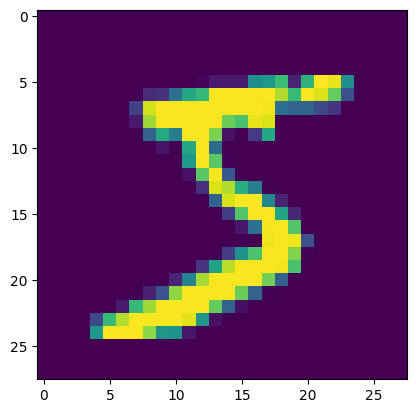

In [40]:
plt.imshow(X_train[0])

In [41]:
X_train = X_train/255
X_test = X_test/255

In [42]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [43]:
X_train_flatted = X_train.reshape(len(X_train),28*28)
X_test_flatted = X_test.reshape(len(X_test),28*28)

In [44]:
cnn = Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [46]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9567 - loss: 0.1431
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9845 - loss: 0.0479
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9892 - loss: 0.0342
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9919 - loss: 0.0248
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9937 - loss: 0.0191
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9954 - loss: 0.0145
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9959 - loss: 0.0118
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9966 - loss: 0.0104
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9972 - loss: 0.0083
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9975 - loss: 0.0073


In [47]:
X_train.shape

(60000, 28, 28)

In [48]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [49]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9874 - loss: 12.9950


[12.99504280090332, 0.9873999953269958]

In [50]:
y_pre = cnn.predict(X_test)
y_pre[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[6.95502544e-11, 1.21602298e-10, 2.73557941e-08, 4.65015724e-08,
        5.96030070e-09, 4.38688946e-11, 9.21345790e-14, 9.99999762e-01,
        2.49255585e-08, 1.41694912e-07],
       [9.77596670e-10, 3.23287512e-12, 1.00000000e+00, 2.96308307e-13,
        1.73852442e-13, 8.37326810e-18, 1.92839269e-11, 6.76209783e-11,
        3.58087171e-11, 1.35539946e-15],
       [3.27299055e-09, 9.99986291e-01, 1.23504638e-08, 7.33311144e-13,
        1.35321270e-05, 2.81736554e-08, 4.54222793e-08, 1.11019745e-07,
        2.81787091e-08, 3.97649941e-10],
       [1.00000000e+00, 2.85012478e-16, 8.14946594e-14, 5.20172674e-15,
        1.32266202e-14, 5.10737177e-13, 1.69110836e-09, 1.88772663e-13,
        3.62746569e-11, 2.23041269e-12],
       [5.95534155e-09, 3.02179437e-08, 8.97832635e-08, 2.85168699e-13,
        9.99995232e-01, 4.30056595e-08, 6.08972872e-11, 1.73482040e-12,
        1.94832501e-06, 2.75159869e-06]], dtype=float32)

In [51]:
y_classes = [np.argmax(element) for element in y_pre]
y_classes[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [52]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)